In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import tables_io
import matplotlib.pyplot as plt 
%matplotlib inline 


In [2]:
setting = 'true_nz/equalredshiftwidth/'
bins = '1_bins'

In [3]:
dir_wide_catalog =  '../job/data/hlwas_cosmos_260120_UM_2026_01_22.parquet'
dir_output = '../job/tomobinning_project_output/' + setting + bins + '/out/'

In [4]:
widegalaxy = tables_io.read(dir_wide_catalog)
widegalaxy_assignment = tables_io.read(dir_output + 'widedata_wide_assignment.hdf5')
tomotbinwide = tables_io.read(dir_output + 'tomo_bins_wide.hdf5')
widebinning = tomotbinwide['tomo_bins_wide'][:,0][widegalaxy_assignment['cells']]
tomotbinwide_ref = h5py.File(dir_output +'FINAL_NZ.hdf5','r')

column_list None


In [5]:
redshiftcol='specz'
zbinsc = tomotbinwide_ref['meta/xvals'][:][0]

In [6]:
tomotbinwide

OrderedDict([('tomo_bins_wide',
              array([[0., 1.],
                     [0., 1.],
                     [0., 1.],
                     ...,
                     [0., 1.],
                     [0., 1.],
                     [0., 1.]], shape=(1024, 2)))])

47499


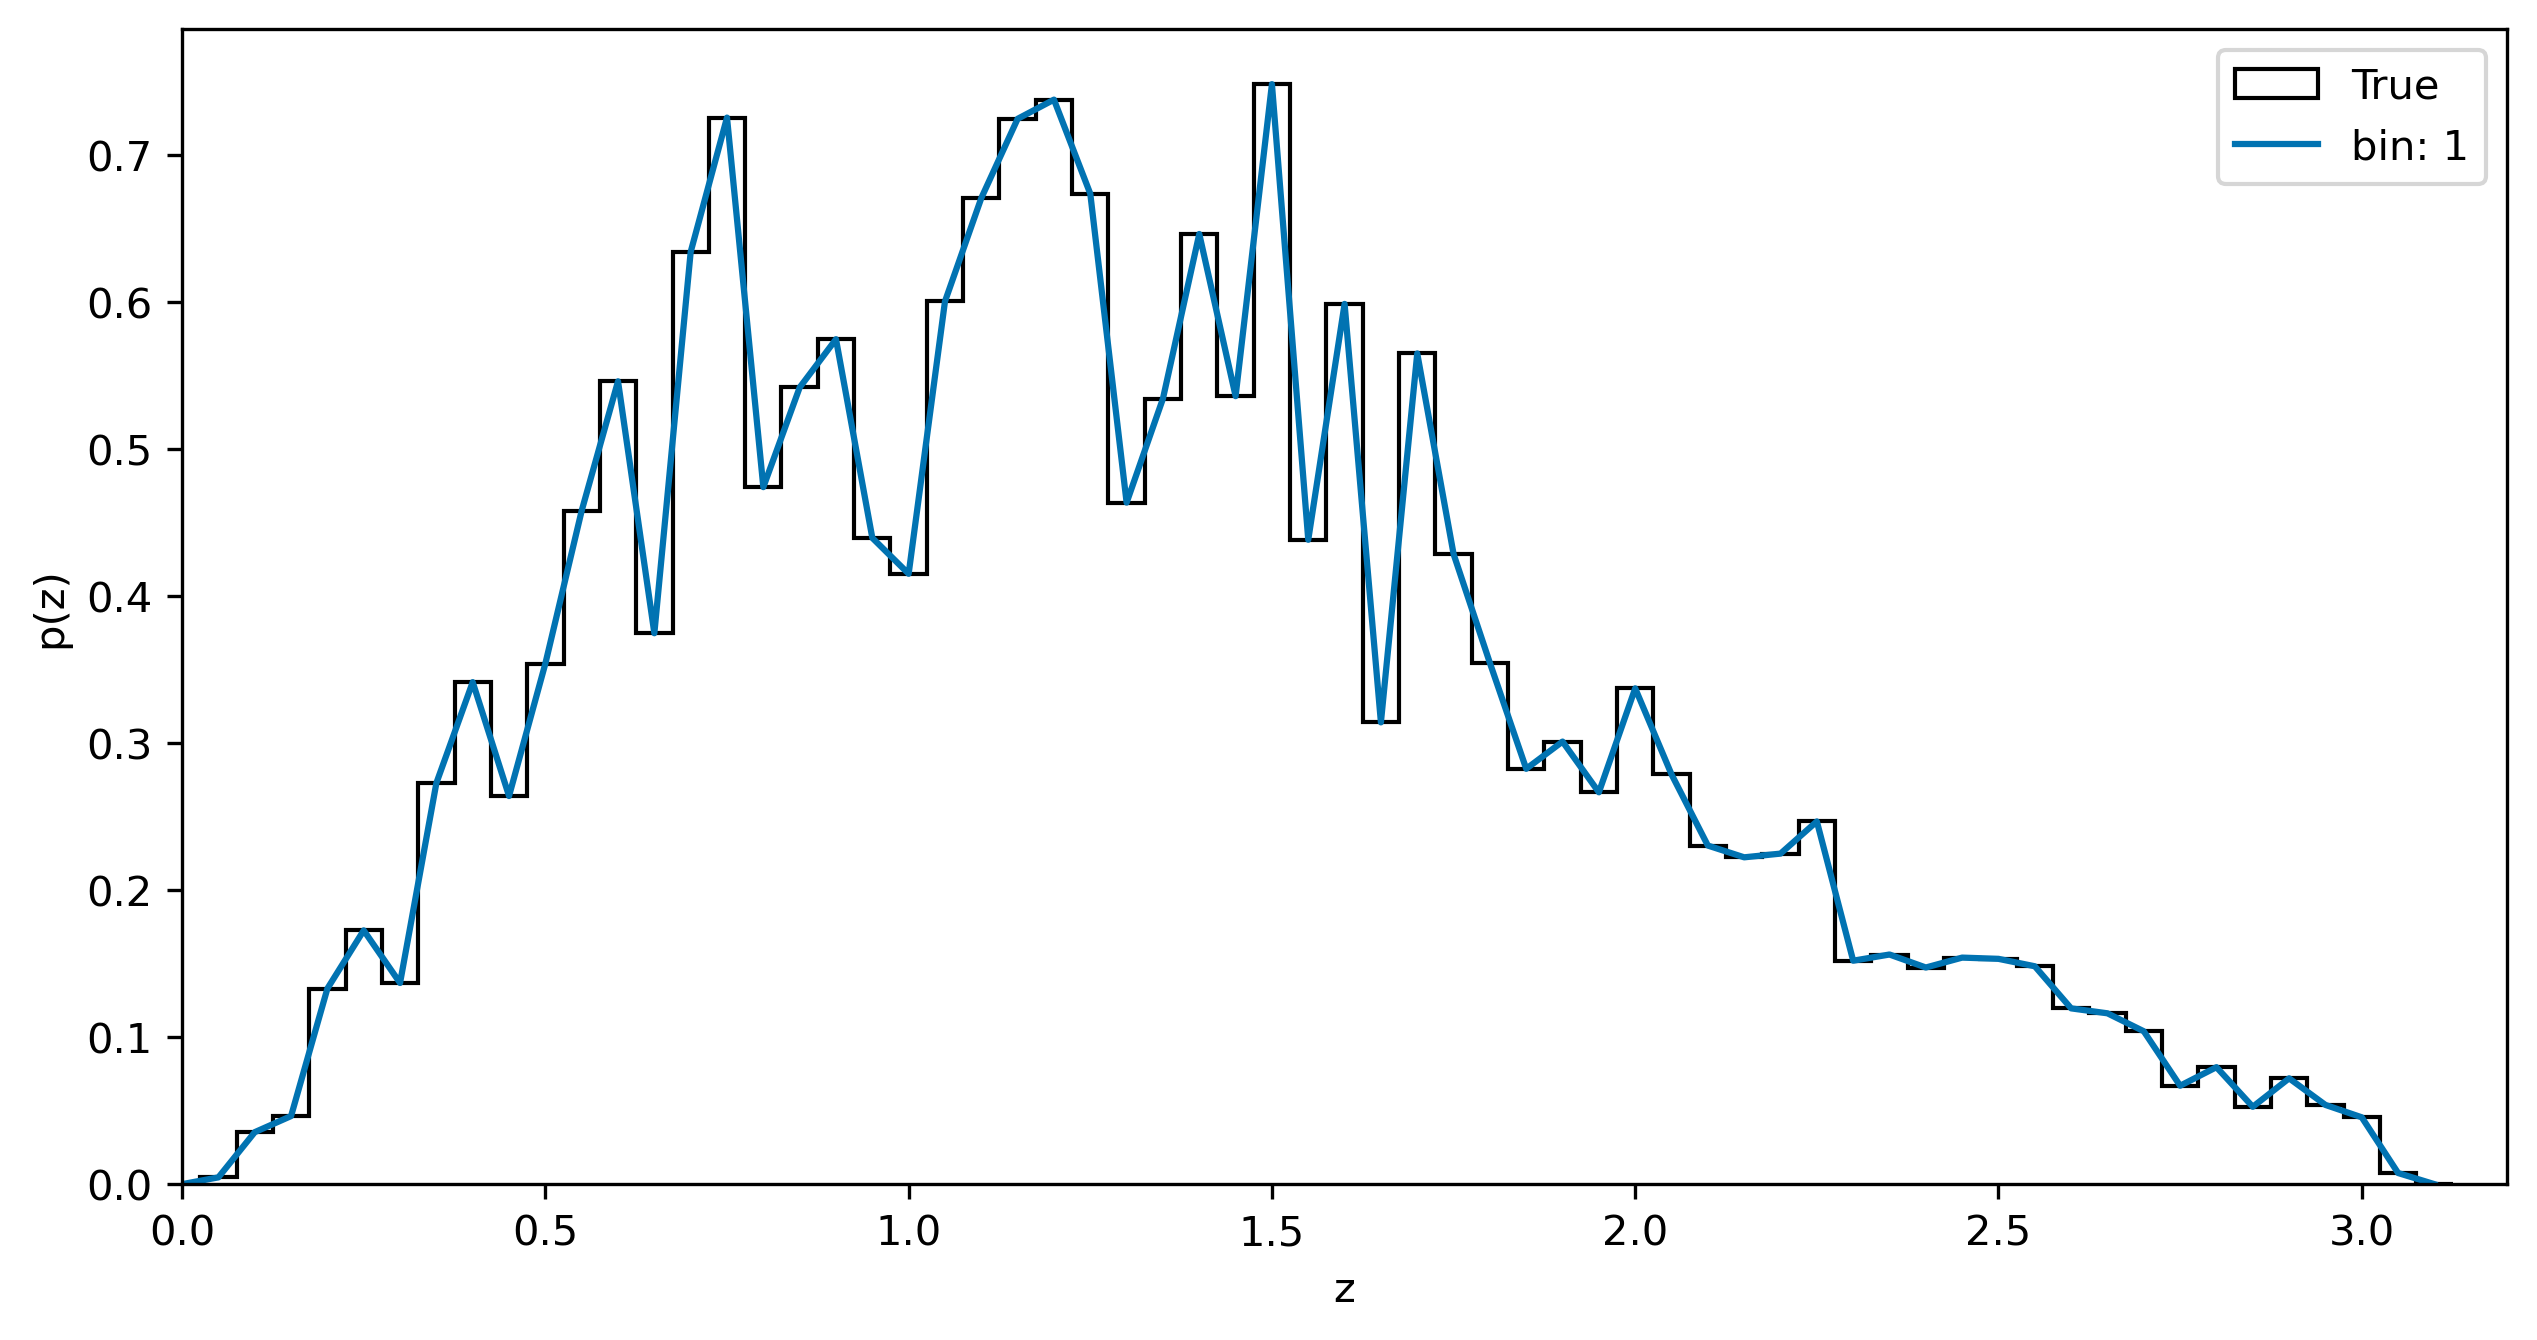

In [7]:
import seaborn as sns
colors = sns.color_palette('colorblind')
fig = plt.figure(figsize=(10,5), dpi = 300)
for i in range(int(np.max(widebinning))+1):
    if i==0:
        name="True"
    else:
        name=None
    bin_edges = np.append(zbinsc - 0.05/2, zbinsc[-1] + 0.05/2)
    plt.hist(np.array(widegalaxy[redshiftcol])[widebinning==i], density=True, histtype="step", bins=bin_edges, color='k', label=name)
    print(len(np.array(widegalaxy[redshiftcol])[widebinning==i]))
    plt.plot(zbinsc,tomotbinwide_ref['data/yvals'][:][i], "-", label="bin: "+str(i+1), c=colors[i])

plt.legend()
plt.xlabel("z")
plt.ylabel("p(z)")
plt.xlim(0,3.2)
plt.savefig('nz_figs/' + setting + bins + '.png')

column_list None


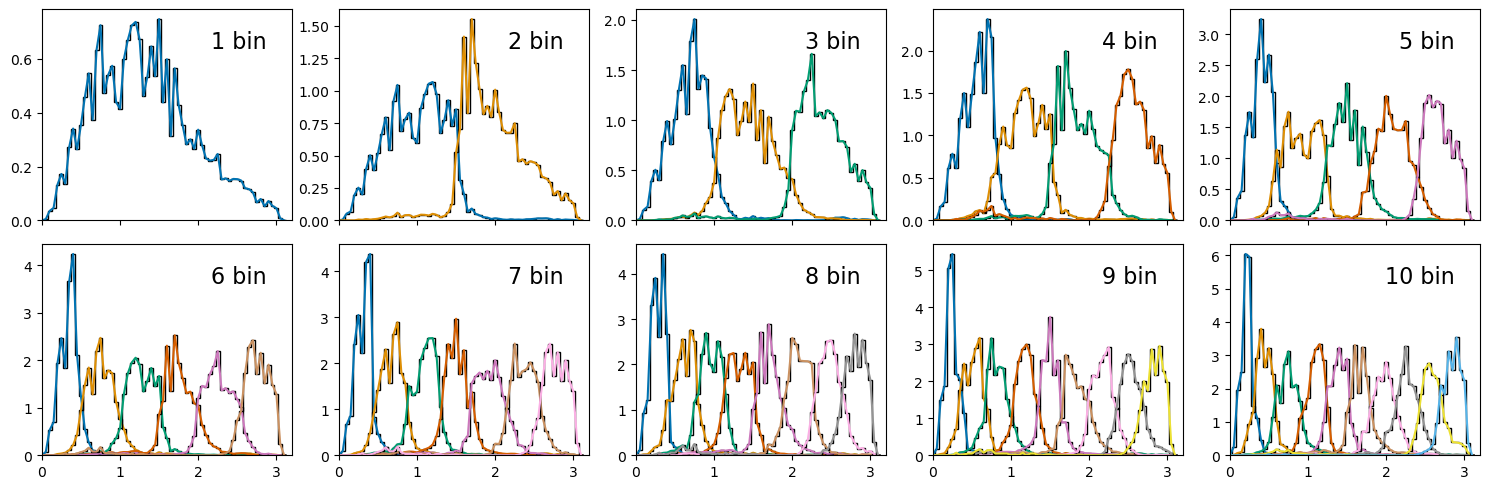

In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import tables_io
import seaborn as sns
from matplotlib.pyplot import subplots

setting = 'true_nz/equalredshiftwidth/'
dir_wide_catalog = '../job/data/hlwas_cosmos_260120_UM_2026_01_22.parquet'
widegalaxy = tables_io.read(dir_wide_catalog)
redshiftcol = 'specz'
colors = sns.color_palette('colorblind', 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharex=True)

for i, ax in enumerate(axes.flatten()):
    num_bins = i + 1
    bins = str(num_bins) + '_bins'
    dir_output = '../job/tomobinning_project_output/' + setting + bins + '/out/'
    
    widegalaxy_assignment = tables_io.read(dir_output + 'widedata_wide_assignment.hdf5')
    tomotbinwide = tables_io.read(dir_output + 'tomo_bins_wide.hdf5')
    widebinning = tomotbinwide['tomo_bins_wide'][:,0][widegalaxy_assignment['cells']]
    
    tomotbinwide_ref = h5py.File(dir_output + 'FINAL_NZ.hdf5', 'r')
    zbinsc = tomotbinwide_ref['meta/xvals'][:][0]
    bin_edges = np.append(zbinsc - 0.05/2, zbinsc[-1] + 0.05/2)
    
    for j in range(int(np.max(widebinning)) + 1):
        mask = widebinning == j
        ax.hist(np.array(widegalaxy[redshiftcol])[mask], density=True, histtype="step", bins=bin_edges, color='k')
        ax.plot(zbinsc, tomotbinwide_ref['data/yvals'][:][j], "-", c=colors[j % len(colors)])
    
    tomotbinwide_ref.close()
    ax.set_xlim(0, 3.2)
    

    ax.text(0.9, 0.9, f'{num_bins} bin', transform=ax.transAxes, ha='right', va='top', fontsize=16, color='black')

plt.tight_layout()
plt.savefig('nz_figs/' + setting + 'all_bins_grid.png', dpi=300)
plt.show()